In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns

NHS_BLUE   = '#185FA5'
NHS_DARK   = '#042C53'
NHS_TEAL   = '#1D9E75'
NHS_CORAL  = '#993C1D'
NHS_AMBER  = '#E8A317'
NHS_LIGHT  = '#E6F1FB'
GRAY_TEXT  = '#5F5E5A'
GRAY_LIGHT = '#F1EFE8'

mpl.rcParams.update({
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : '#FAFAFA',
    'axes.edgecolor'      : '#D3D1C7',
    'axes.linewidth'      : 1.0,
    'axes.titlesize'      : 14,
    'axes.titleweight'    : 'bold',
    'axes.titlecolor'     : NHS_DARK,
    'axes.titlepad'       : 15,
    'axes.labelsize'      : 11,
    'axes.labelcolor'     : GRAY_TEXT,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'xtick.color'         : GRAY_TEXT,
    'ytick.color'         : GRAY_TEXT,
    'legend.fontsize'     : 10,
    'legend.framealpha'   : 1.0,
    'legend.edgecolor'    : '#D3D1C7',
    'figure.dpi'          : 120,
    'savefig.dpi'         : 200,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
    'font.family'         : 'sans-serif',
    'grid.color'          : '#E8E6DF',
    'grid.linewidth'      : 0.5,
})


In [2]:
df = pd.read_csv(
    "../data/cleaned/ae_clean.csv",
    parse_dates=['period'])

print(f"Rows: {len(df)}")
print(f"Trusts: {df['org_name'].nunique()}")
print(f"Date range: {df['period'].min().strftime('%b %Y')} "
      f"to {df['period'].max().strftime('%b %Y')}")
print(f"Breach rate: {df['breach'].mean()*100:.1f}%")

Rows: 4475
Trusts: 203
Date range: Apr 2024 to Mar 2026
Breach rate: 68.9%


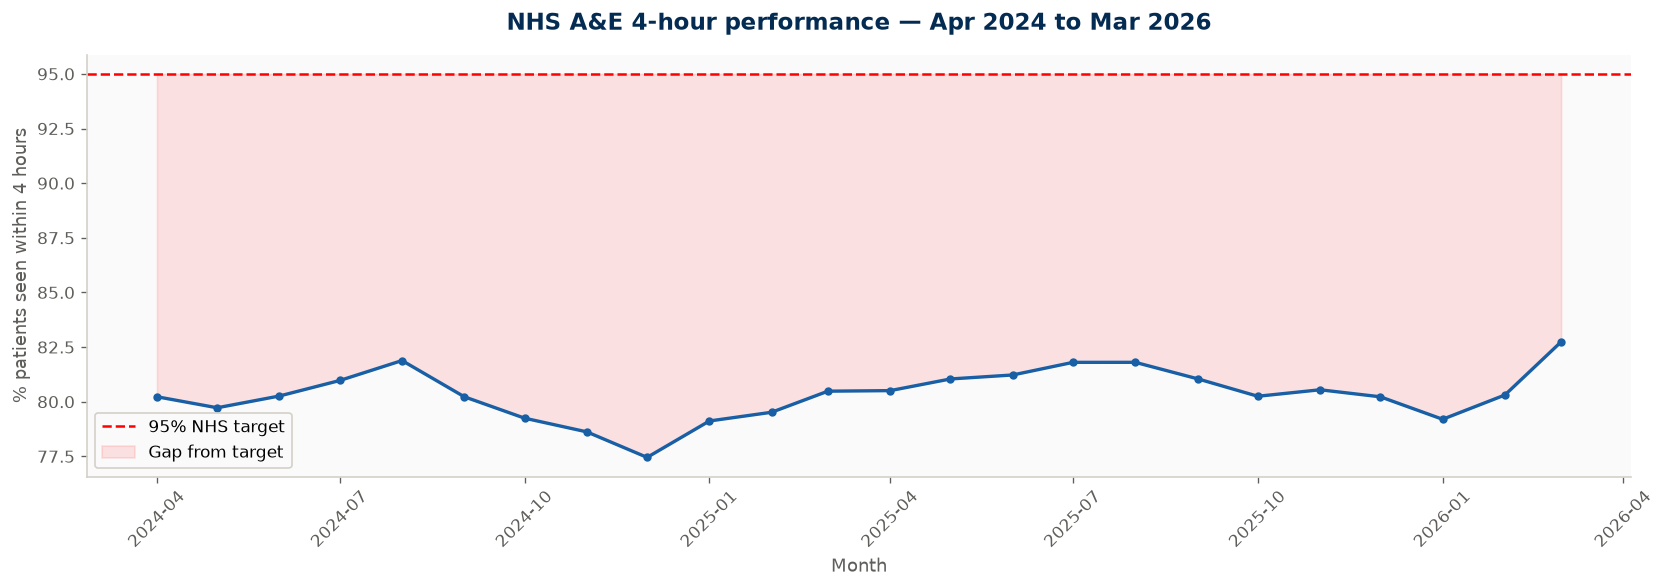

In [3]:
# Monthly average performance across all trusts
monthly = df.groupby('period')['pct_within_4hr'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly['period'], monthly['pct_within_4hr'],
         color='#185FA5', linewidth=2, marker='o', markersize=4)

# Add the 95% target line
plt.axhline(y=95, color='red', linestyle='--',
            linewidth=1.5, label='95% NHS target')

plt.fill_between(monthly['period'], monthly['pct_within_4hr'],
                 95, alpha=0.1, color='red', label='Gap from target')

plt.title('NHS A&E 4-hour performance — Apr 2024 to Mar 2026',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('% patients seen within 4 hours')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../output-files/01_monthly_performance.png', dpi=150)
plt.show()

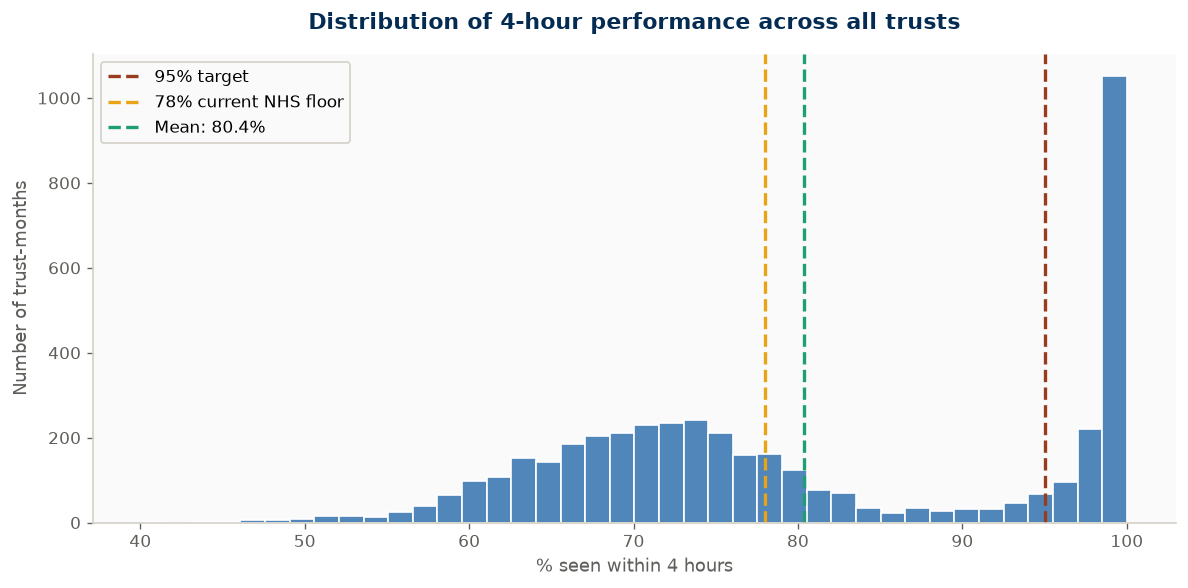

In [4]:
plt.figure(figsize=(10, 5))

sns.histplot(df['pct_within_4hr'], bins=40,
             color=NHS_BLUE, edgecolor='white')

plt.axvline(x=95, color=NHS_CORAL, linestyle='--',
            linewidth=2, label='95% target')
plt.axvline(x=78, color=NHS_AMBER, linestyle='--',
            linewidth=2, label='78% current NHS floor')
plt.axvline(x=df['pct_within_4hr'].mean(), color=NHS_TEAL,
            linestyle='--', linewidth=2,
            label=f"Mean: {df['pct_within_4hr'].mean():.1f}%")

plt.title('Distribution of 4-hour performance across all trusts',
          fontsize=13, fontweight='bold')
plt.xlabel('% seen within 4 hours')
plt.ylabel('Number of trust-months')
plt.legend()
plt.tight_layout()
plt.savefig('../output-files/02_performance_distribution.png', dpi=150)
plt.show()

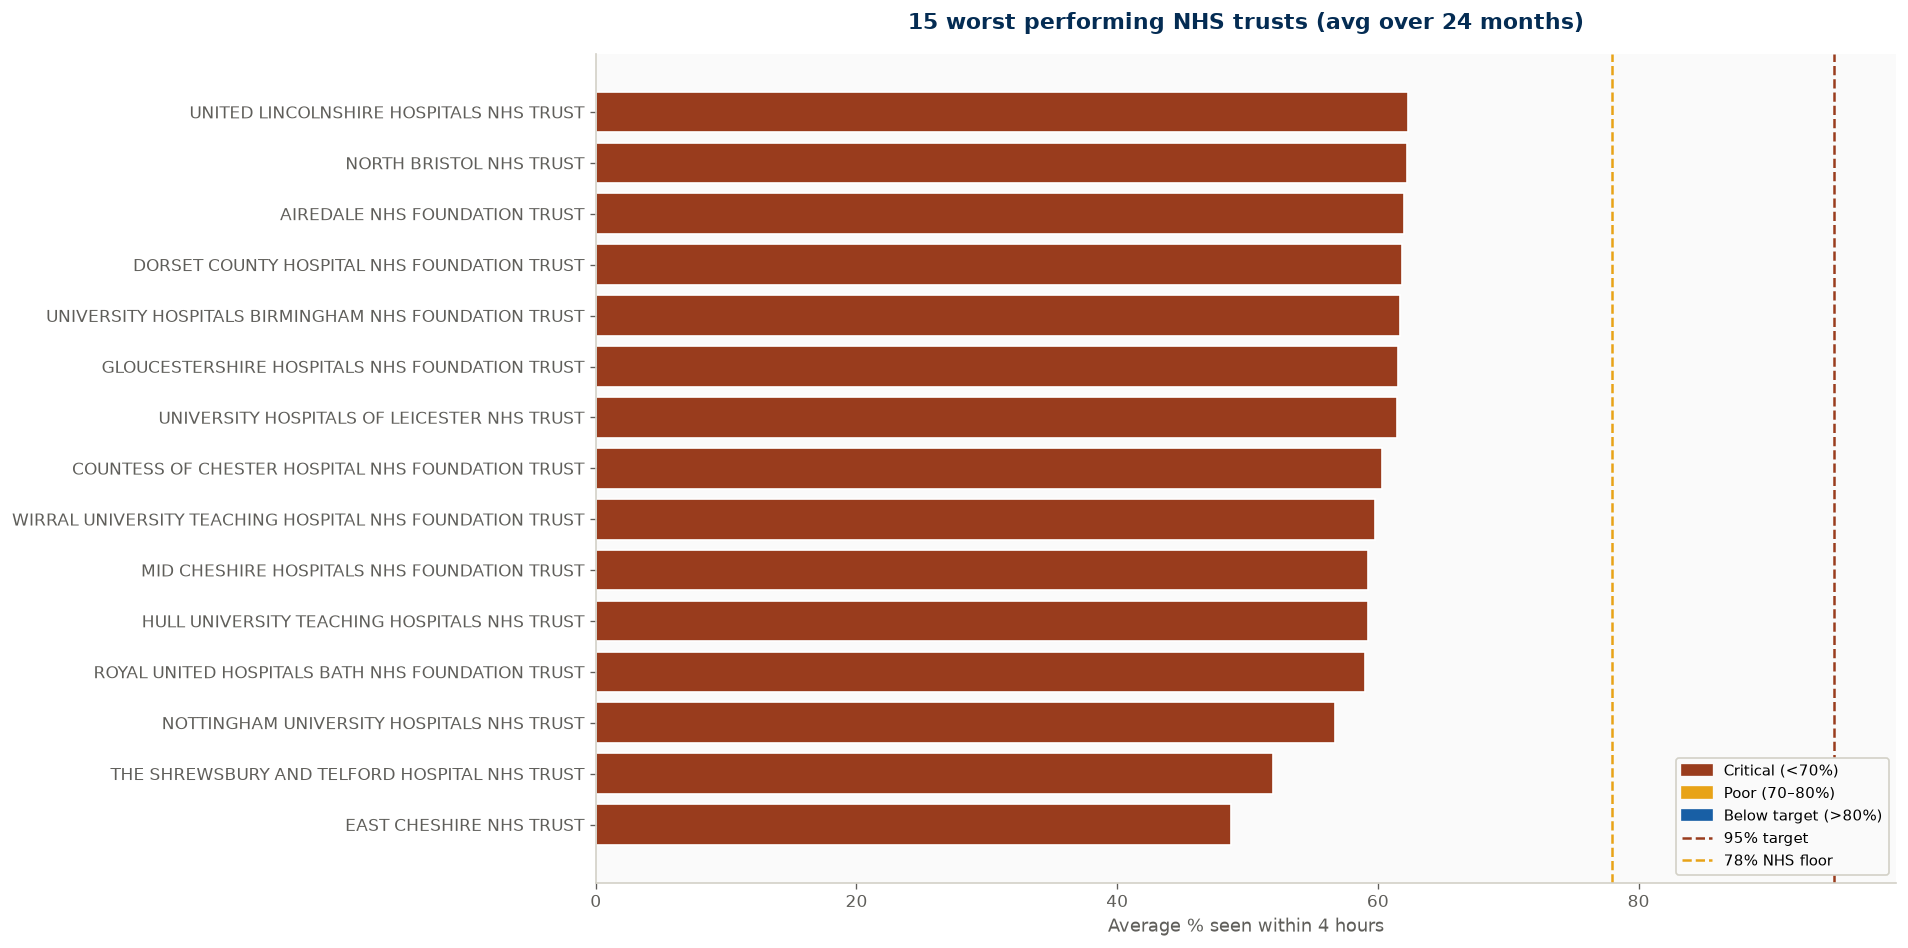

In [5]:
# Average performance per trust over all months
trust_perf = df.groupby('org_name')['pct_within_4hr'].mean().reset_index()
trust_perf = trust_perf.sort_values('pct_within_4hr').head(15)

plt.figure(figsize=(16, 8))

bar_colors = [NHS_CORAL if v < 70
              else NHS_AMBER if v < 80
              else NHS_BLUE
              for v in trust_perf['pct_within_4hr']]

bars = plt.barh(trust_perf['org_name'],
                trust_perf['pct_within_4hr'],
                color=bar_colors, edgecolor='white')

plt.axvline(x=95, color=NHS_CORAL, linestyle='--',
            linewidth=1.5, label='95% target')
plt.axvline(x=78, color=NHS_AMBER, linestyle='--',
            linewidth=1.5, label='78% current NHS floor')

plt.title('15 worst performing NHS trusts (avg over 24 months)',
          fontsize=13, fontweight='bold')
plt.xlabel('Average % seen within 4 hours')

plt.legend(handles=[
    mpatches.Patch(color=NHS_CORAL, label='Critical (<70%)'),
    mpatches.Patch(color=NHS_AMBER, label='Poor (70–80%)'),
    mpatches.Patch(color=NHS_BLUE,  label='Below target (>80%)'),
    plt.Line2D([0],[0], color=NHS_CORAL,
               linestyle='--', label='95% target'),
    plt.Line2D([0],[0], color=NHS_AMBER,
               linestyle='--', label='78% NHS floor'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../output-files/03_worst_trusts.png', dpi=150)
plt.show()

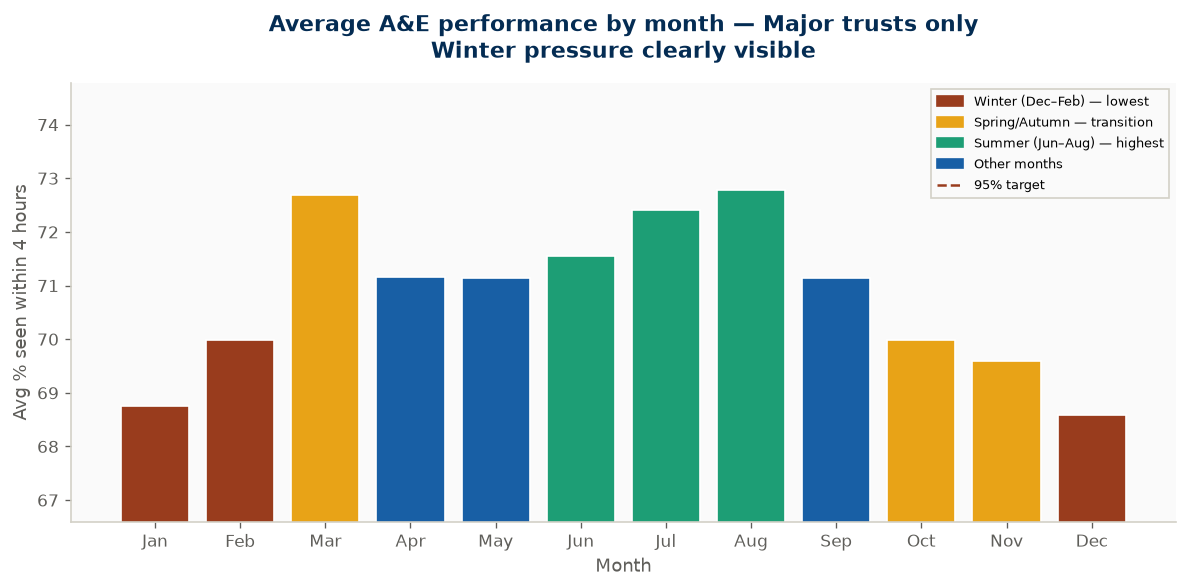

In [6]:
# Create month column first
df['month'] = df['period'].dt.month
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# Filter to Type 1 major trusts only
type1_df = df[df['att_type1'] > 1000]
monthly_avg = type1_df.groupby('month')['pct_within_4hr'].mean()

plt.figure(figsize=(10, 5))

colors = [NHS_CORAL if m in [12, 1, 2]
          else NHS_AMBER if m in [3, 10, 11]
          else NHS_TEAL if m in [6, 7, 8]
          else NHS_BLUE
          for m in monthly_avg.index]

plt.bar(monthly_avg.index, monthly_avg.values,
        color=colors, edgecolor='white')

plt.ylim([monthly_avg.min() - 2, monthly_avg.max() + 2])

plt.axhline(y=95, color=NHS_CORAL, linestyle='--',
            linewidth=1.5, label='95% target')

plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.title('Average A&E performance by month — Major trusts only\n'
          'Winter pressure clearly visible',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg % seen within 4 hours')

plt.legend(handles=[
    mpatches.Patch(color=NHS_CORAL, label='Winter (Dec–Feb) — lowest'),
    mpatches.Patch(color=NHS_AMBER, label='Spring/Autumn — transition'),
    mpatches.Patch(color=NHS_TEAL,  label='Summer (Jun–Aug) — highest'),
    mpatches.Patch(color=NHS_BLUE,  label='Other months'),
    plt.Line2D([0],[0], color=NHS_CORAL,
               linestyle='--', label='95% target'),
], loc='upper right', fontsize=8,
   framealpha=1.0, edgecolor='#D3D1C7',
   fancybox=False)

plt.tight_layout()
plt.savefig('../output-files/04_seasonal_pattern.png', dpi=150)
plt.show()

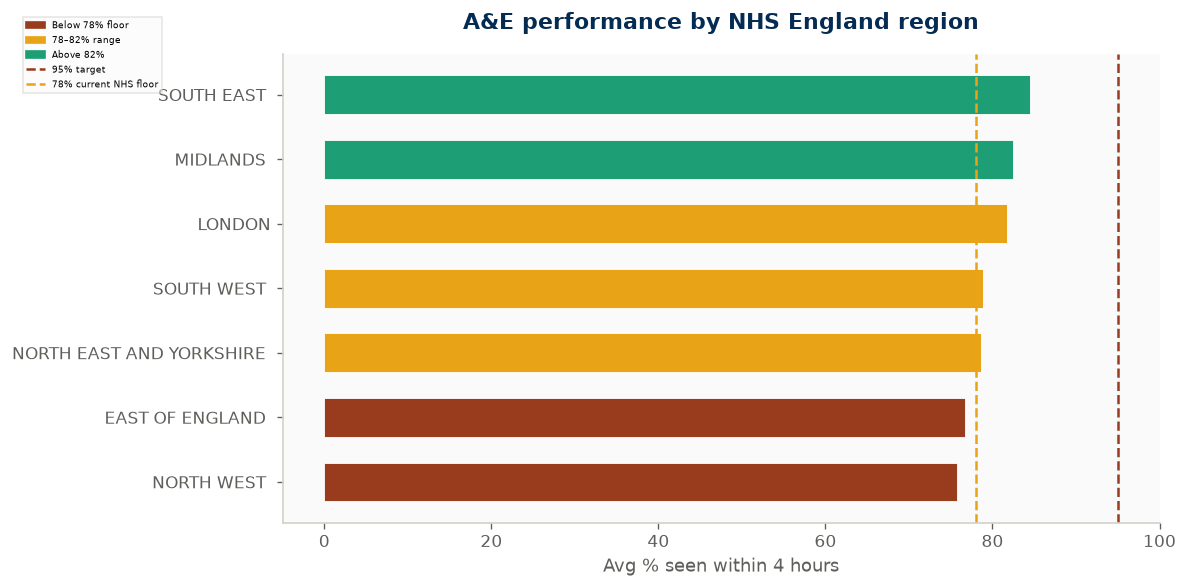

In [7]:
region_perf = df.groupby('parent_org')['pct_within_4hr'].mean().reset_index()
region_perf = region_perf.sort_values('pct_within_4hr')

region_perf['parent_org'] = region_perf['parent_org'].str.replace(
    'NHS ENGLAND ', '', regex=False)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [NHS_CORAL if v < 78
              else NHS_AMBER if v < 82
              else NHS_TEAL
              for v in region_perf['pct_within_4hr']]

ax.barh(region_perf['parent_org'],
        region_perf['pct_within_4hr'],
        color=bar_colors, edgecolor='white',
        linewidth=0.5, height=0.6)

ax.axvline(x=95, color=NHS_CORAL, linestyle='--', linewidth=1.5)
ax.axvline(x=78, color=NHS_AMBER, linestyle='--', linewidth=1.5)

ax.set_title('A&E performance by NHS England region',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Avg % seen within 4 hours')
ax.set_xlim([-5, 100])

fig.legend(handles=[
    mpatches.Patch(color=NHS_CORAL, label='Below 78% floor'),
    mpatches.Patch(color=NHS_AMBER, label='78–82% range'),
    mpatches.Patch(color=NHS_TEAL,  label='Above 82%'),
    plt.Line2D([0],[0], color=NHS_CORAL,
               linestyle='--', label='95% target'),
    plt.Line2D([0],[0], color=NHS_AMBER,
               linestyle='--', label='78% current NHS floor'),
], fontsize=5.5,
   framealpha=0.5,
   edgecolor='#D3D1C7',
   fancybox=False,
   loc='upper left',
   bbox_to_anchor=(0.02, 0.97))

plt.tight_layout()
plt.savefig('../output-files/05_regional_performance.png', dpi=150)
plt.show()